# CIFAR-10 Dataset Inspection

**Dataset:** [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)

## 1. Setup

In [21]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
DATA_DIR = Path("dataset")
ANALYSIS_DIR = DATA_DIR / "analysis"

# Same seed everywhere so the later random samples/plots stay reproducible.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR.mkdir(exist_ok=True)
ANALYSIS_DIR.mkdir(exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Dataset directory: {DATA_DIR.resolve()}")

PyTorch: 2.13.0
CUDA available: False
Dataset directory: /Users/branko.grbic/Documents/Faculty/MATF-MU-2026-DDPM-Implementation/dataset


## 2. Download and load CIFAR-10

In [22]:
download = not (DATA_DIR / "cifar-10-batches-py" / "test_batch").exists()
train_raw = datasets.CIFAR10(root=DATA_DIR, train=True, download=download)
test_raw = datasets.CIFAR10(root=DATA_DIR, train=False, download=download)

# Look at raw uint8 pixels first (32x32 RGB, 0–255) before any DDPM scaling.
class_names = train_raw.classes
train_images = np.asarray(train_raw.data)
test_images = np.asarray(test_raw.data)
train_labels = np.asarray(train_raw.targets)
test_labels = np.asarray(test_raw.targets)

split_summary = pd.DataFrame(
    {
        "images": [len(train_images), len(test_images)],
        "shape": [str(train_images.shape[1:]), str(test_images.shape[1:])],
        "dtype": [train_images.dtype, test_images.dtype],
        "minimum": [train_images.min(), test_images.min()],
        "maximum": [train_images.max(), test_images.max()],
    },
    index=["train", "test"],
)

display(split_summary)
print(f"Classes ({len(class_names)}): {class_names}")

,images,shape,dtype,minimum,maximum
train,50000,"(32, 32, 3)",uint8,0,255
test,10000,"(32, 32, 3)",uint8,0,255


Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Class distribution and balance

,min_count,max_count,mean_count,std_count,max_to_min_ratio
split,,,,,
test,1000,1000,1000.0,0.0,1.0
train,5000,5000,5000.0,0.0,1.0


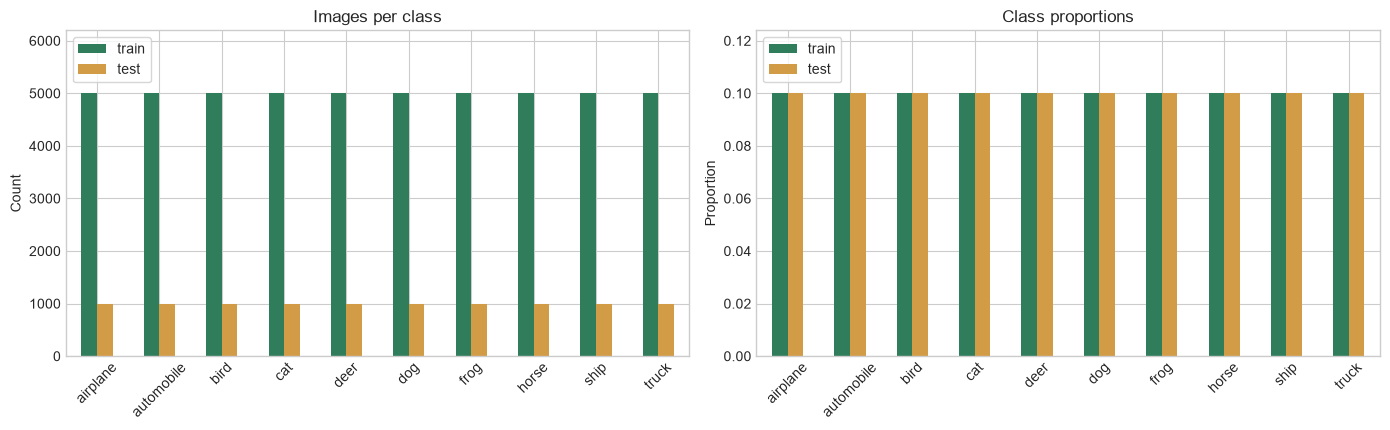

In [23]:
def class_distribution(labels, split):
    counts = np.bincount(labels, minlength=len(class_names))
    return pd.DataFrame(
        {
            "split": split,
            "class": class_names,
            "count": counts,
            "proportion": counts / counts.sum(),
        }
    )

distribution = pd.concat(
    [class_distribution(train_labels, "train"), class_distribution(test_labels, "test")],
    ignore_index=True,
)

balance_metrics = distribution.groupby("split")["count"].agg(
    min_count="min", max_count="max", mean_count="mean", std_count="std"
)
balance_metrics["max_to_min_ratio"] = (
    balance_metrics["max_count"] / balance_metrics["min_count"]
)
display(balance_metrics)

counts = distribution.pivot(index="class", columns="split", values="count").loc[class_names, ["train", "test"]]
proportions = distribution.pivot(index="class", columns="split", values="proportion").loc[class_names, ["train", "test"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
counts.plot.bar(ax=axes[0], color=["#2f7d5b", "#d29b45"], legend=False)
proportions.plot.bar(ax=axes[1], color=["#2f7d5b", "#d29b45"], legend=False)
axes[0].set(title="Images per class", ylabel="Count", xlabel="")
axes[1].set(title="Class proportions", ylabel="Proportion", xlabel="")
for axis in axes:
    axis.tick_params(axis="x", rotation=45)
    axis.set_ylim(0, axis.get_ylim()[1] * 1.18)
    axis.legend(["train", "test"], loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

## 4. Visual inspection

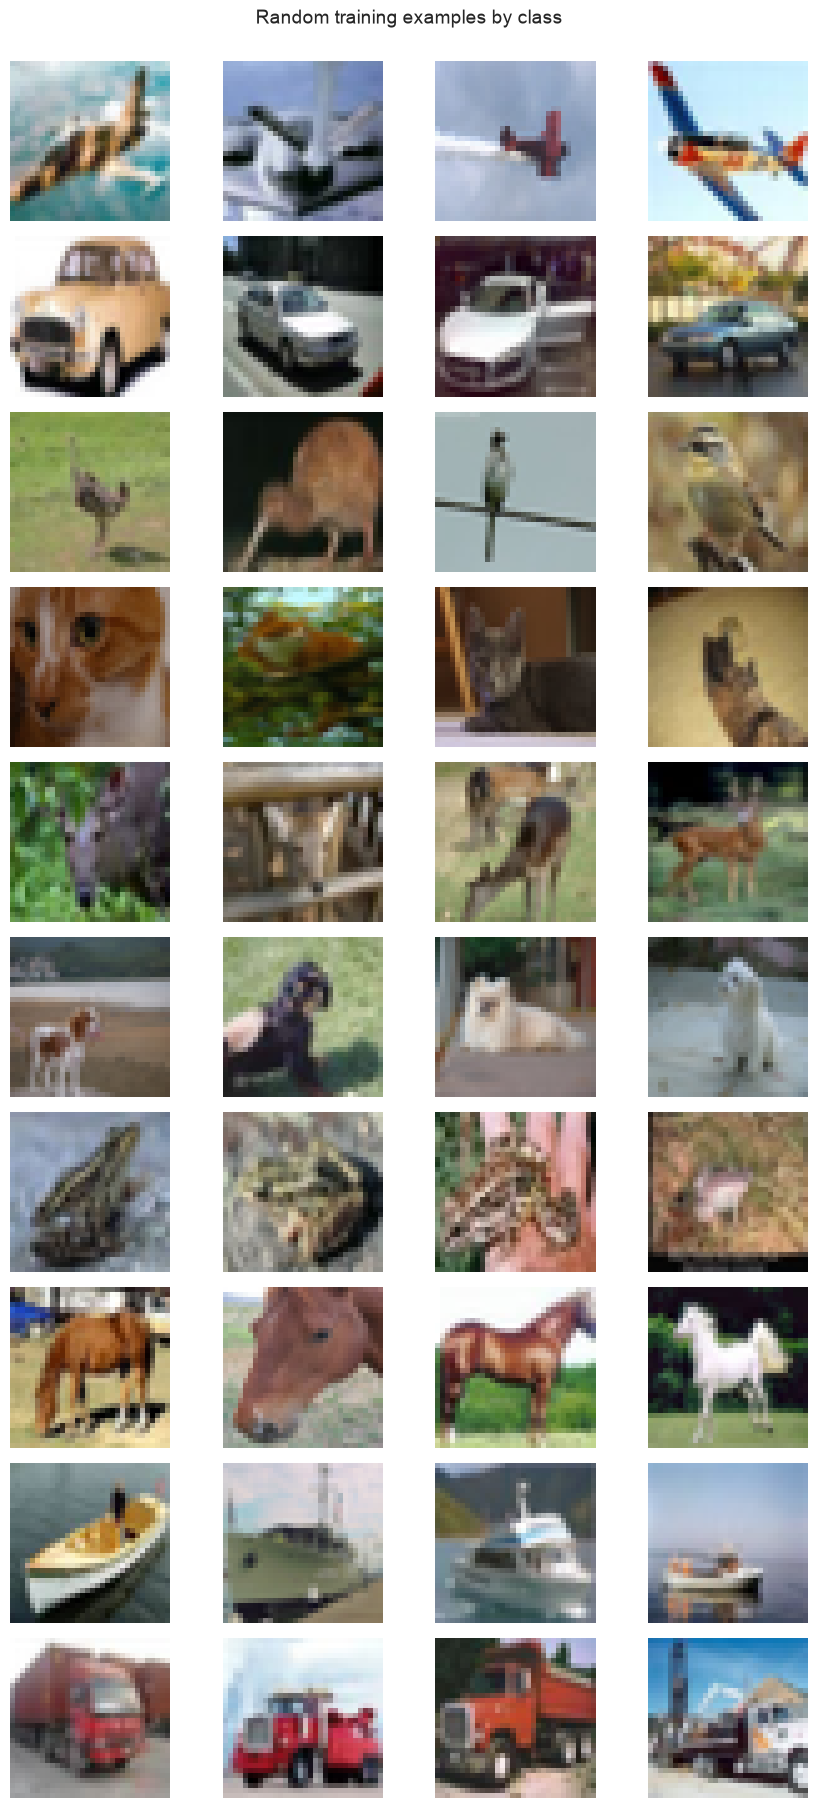

In [24]:
def show_class_examples(images, labels, samples_per_class=4):
    rng = np.random.default_rng(SEED)
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(9, 18))

    for class_index, class_name in enumerate(class_names):
        candidates = np.flatnonzero(labels == class_index)
        selected = rng.choice(candidates, size=samples_per_class, replace=False)
        for column, image_index in enumerate(selected):
            axes[class_index, column].imshow(images[image_index])
            axes[class_index, column].axis("off")
        axes[class_index, 0].set_ylabel(class_name, rotation=0, labelpad=35, va="center")

    fig.suptitle("Random training examples by class", y=1.002, fontsize=14)
    plt.tight_layout()
    plt.show()


show_class_examples(train_images, train_labels)

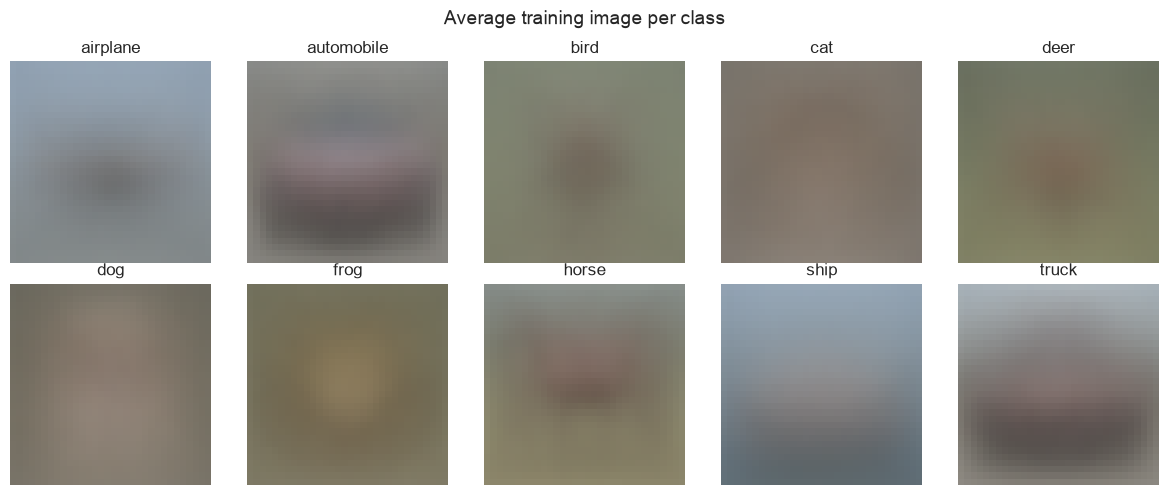

In [25]:
# Mean image per class, check if the class has a consistent spatial layout.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_index, axis in enumerate(axes.flat):
    mean_image = train_images[train_labels == class_index].mean(axis=0) / 255.0
    axis.imshow(mean_image)
    axis.set_title(class_names[class_index])
    axis.axis("off")

fig.suptitle("Average training image per class", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Pixel and channel statistics

,split,channel,mean_0_1,std_0_1,mean_minus1_1,std_minus1_1
0,train,R,0.4914,0.2470,-0.0172,0.4941
1,train,G,0.4822,0.2435,-0.0357,0.4870
2,train,B,0.4465,0.2616,-0.1069,0.5232
3,test,R,0.4942,0.2467,-0.0116,0.4933
4,test,G,0.4851,0.2429,-0.0297,0.4858
5,test,B,0.4504,0.2616,-0.0992,0.5232


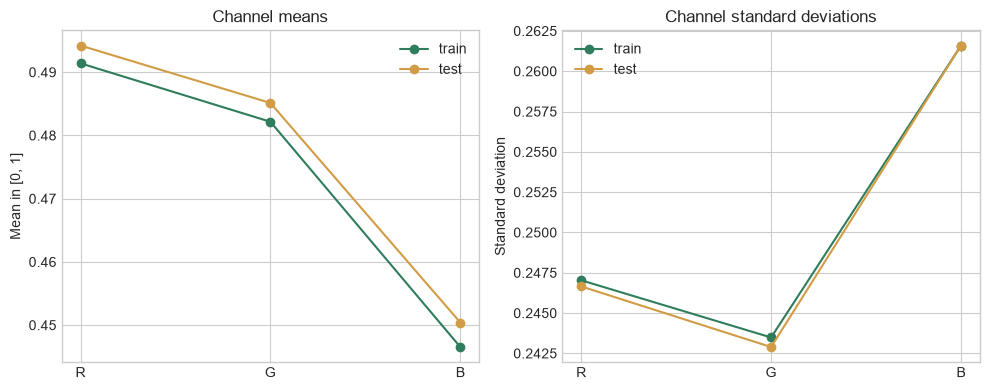

In [26]:
def channel_statistics(images, chunk_pixels=1_000_000):
    pixels = images.reshape(-1, 3)
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_square_sum = np.zeros(3, dtype=np.float64)

    # Chunking avoids a full floating-point copy of the dataset.
    for start in range(0, len(pixels), chunk_pixels):
        chunk = pixels[start : start + chunk_pixels].astype(np.float64) / 255.0
        channel_sum += chunk.sum(axis=0)
        channel_square_sum += np.square(chunk).sum(axis=0)

    mean = channel_sum / len(pixels)
    variance = channel_square_sum / len(pixels) - np.square(mean)
    return mean, np.sqrt(np.maximum(variance, 0.0))


channel_rows = []
for split, images in [("train", train_images), ("test", test_images)]:
    mean, std = channel_statistics(images)
    for channel, channel_mean, channel_std in zip("RGB", mean, std):
        channel_rows.append(
            {
                "split": split,
                "channel": channel,
                "mean_0_1": channel_mean,
                "std_0_1": channel_std,
                "mean_minus1_1": 2 * channel_mean - 1,
                "std_minus1_1": 2 * channel_std,
            }
        )

channel_stats = pd.DataFrame(channel_rows)
display(channel_stats.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for split, color in [("train", "#2f7d5b"), ("test", "#d29b45")]:
    subset = channel_stats[channel_stats["split"] == split]
    axes[0].plot(subset["channel"], subset["mean_0_1"], marker="o", label=split, color=color)
    axes[1].plot(subset["channel"], subset["std_0_1"], marker="o", label=split, color=color)
axes[0].set(title="Channel means", ylabel="Mean in [0, 1]")
axes[1].set(title="Channel standard deviations", ylabel="Standard deviation")
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()

## 6. Simple class-level image properties

,brightness,contrast,red_mean,green_mean,blue_mean
class,,,,,
airplane,0.5583,0.2044,0.5257,0.5603,0.5889
automobile,0.4576,0.2371,0.4712,0.4545,0.4472
bird,0.4683,0.1823,0.4892,0.4915,0.4240
cat,0.4558,0.2168,0.4955,0.4564,0.4155
deer,0.4383,0.1788,0.4716,0.4652,0.3782
dog,0.4604,0.2172,0.4999,0.4646,0.4165
frog,0.4179,0.1872,0.4701,0.4384,0.3452
horse,0.4662,0.2212,0.5020,0.4799,0.4169
ship,0.5234,0.2159,0.4902,0.5254,0.5547


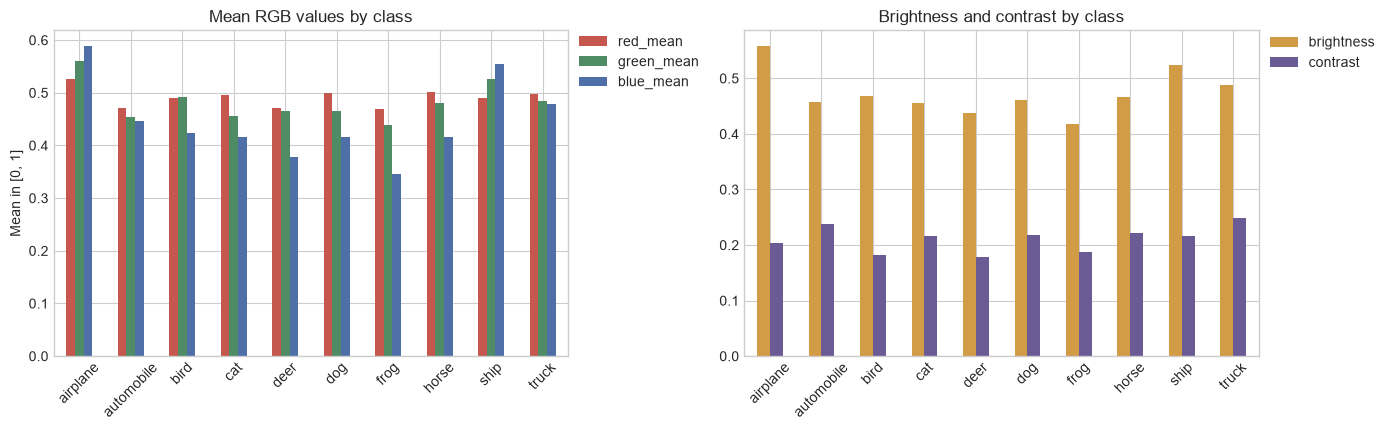

In [27]:
rgb_mean_per_image = train_images.mean(axis=(1, 2)) / 255.0
image_properties = pd.DataFrame(
    {
        "class": [class_names[label] for label in train_labels],
        "brightness": rgb_mean_per_image.mean(axis=1),
        "contrast": train_images.std(axis=(1, 2, 3)) / 255.0,
        "red_mean": rgb_mean_per_image[:, 0],
        "green_mean": rgb_mean_per_image[:, 1],
        "blue_mean": rgb_mean_per_image[:, 2],
    }
)

class_properties = image_properties.groupby("class", sort=False).mean().loc[class_names]
display(class_properties.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
class_properties[["red_mean", "green_mean", "blue_mean"]].plot.bar(
    ax=axes[0], color=["#c6574f", "#4f8c65", "#4f6fa8"]
)
class_properties[["brightness", "contrast"]].plot.bar(
    ax=axes[1], color=["#d29b45", "#6b5b95"]
)
axes[0].set(title="Mean RGB values by class", xlabel="", ylabel="Mean in [0, 1]")
axes[1].set(title="Brightness and contrast by class", xlabel="")
for axis, ncol in zip(axes, (3, 2)):
    axis.tick_params(axis="x", rotation=45)
    # Put the legend under the class names so it cannot cover airplane or truck.
    axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.42), ncol=ncol, frameon=False)
plt.tight_layout()
plt.show()

## 7. Local spatial structure

,correlation
horizontal neighbors,0.9320
vertical neighbors,0.9202
random pixel pairs,0.0024


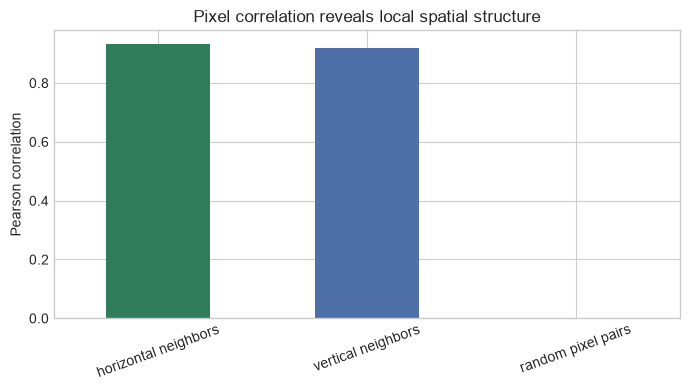

In [28]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(train_images), size=2_000, replace=False)
grayscale = train_images[sample_indices].mean(axis=-1).astype(np.float32) / 255.0

horizontal_correlation = np.corrcoef(
    grayscale[:, :, :-1].ravel(), grayscale[:, :, 1:].ravel()
)[0, 1]
vertical_correlation = np.corrcoef(
    grayscale[:, :-1, :].ravel(), grayscale[:, 1:, :].ravel()
)[0, 1]
random_correlation = np.corrcoef(
    rng.choice(grayscale.ravel(), size=500_000),
    rng.choice(grayscale.ravel(), size=500_000),
)[0, 1]

spatial_stats = pd.Series(
    {
        "horizontal neighbors": horizontal_correlation,
        "vertical neighbors": vertical_correlation,
        "random pixel pairs": random_correlation,
    },
    name="correlation",
)
display(spatial_stats.to_frame().round(4))

spatial_stats.plot.bar(figsize=(7, 4), color=["#2f7d5b", "#4f6fa8", "#b6b6b6"])
plt.title("Pixel correlation reveals local spatial structure")
plt.ylabel("Pearson correlation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 8. Verify the model-ready transform

In [29]:
# Same recipe as the DDPM paper: random flip, then map [0, 1] tensors to [-1, 1].
diffusion_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_dataset = datasets.CIFAR10(
    root=DATA_DIR, train=True, download=False, transform=diffusion_transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,  # drop a leftover smaller batch so training steps stay the same size
)

# Labels come with CIFAR-10 but this DDPM is unconditional, so we ignore them.
image_batch, _ = next(iter(train_loader))
print(f"Batch shape: {tuple(image_batch.shape)}")
print(f"Value range: [{image_batch.min():.3f}, {image_batch.max():.3f}]")
print(f"Batch mean/std: {image_batch.mean():.3f} / {image_batch.std():.3f}")

# Sanity check: NCHW batch, values in [-1, 1] like the rest of the DDPM pipeline expects.
assert image_batch.shape == (32, 3, 32, 32)
assert image_batch.min() >= -1 and image_batch.max() <= 1

Batch shape: (32, 3, 32, 32)
Value range: [-1.000, 1.000]
Batch mean/std: -0.046 / 0.535
